### Проект Чигирной Александры 1 курс магистратуры

# Прогнозирование кредитного риска клиентов банка на основе их финансовой истории и поведенческих характеристик

### Описание проекта
Цель проекта: построить бинарный классификатор для предсказания вероятности дефолта клиента на основе его кредитной истории и поведенческих признаков.

Датасет содержит информацию о клиентах:

- кредитная нагрузка;
- просрочки платежей;
- количество кредитов;
- доход;
- возраст;
- долговые обязательства.

Целевая переменная: SeriousDlqin2yrs (серьезный дефолт в течение 2-х лет)

1 - клиент допустил серьёзную просрочку в течение 2 лет;
0 - клиент не допустил серьёзную просрочку.

## Размер датасета

Train ~150 000 объектов (11 признаков + target) Test - отдельный тестовый набор.

## Описание признаков

- RevolvingUtilizationOfUnsecuredLines - доля использования необеспеченных кредитных линий
- age - возраст клиента
- NumberOfTime30-59DaysPastDueNotWorse - количество просрочек 30-59 дней
- DebtRatio - отношение долга к доходу
- MonthlyIncome - ежемесячный доход
- NumberOfOpenCreditLinesAndLoans - количество открытых кредитов
- NumberOfTimes90DaysLate - количество просрочек более 90 дней
- NumberRealEstateLoansOrLines - количество ипотечных/имущественных кредитов
- NumberOfTime60-89DaysPastDueNotWorse - просрочки 60-89 дней
- NumberOfDependents - количество иждивенцев
- Unnamed: 0 - порядковый номер клиента 

## 1. Почему задача важна? 

Кредитный скоринг является одной из наиболее важных задач в банковской сфере. Перед выдачей кредита финансовая организация должна оценить вероятность того, что клиент не сможет своевременно выполнять свои долговые обязательства. Ошибки в оценке кредитного риска могут привести к существенным финансовым потерям. Если банк выдаёт кредит клиенту с высоким риском дефолта, это увеличивает вероятность невозврата денежных средств. С другой стороны, чрезмерно консервативная политика может привести к потере надёжных клиентов. Цель данного проекта заключается в построении модели машинного обучения для прогнозирования вероятности дефолта клиента на основе информации о его кредитной истории, долговой нагрузке и финансовом положении.

## 2. Загрузка нужных библиотек и данных

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
import gdown

# ID файлов из ссылок
train_file_id = "1SfFIMPrenmABCzQmaq1fLxk4l9uUhZSe"
test_file_id = "1CdDfiBh9bDdxArWPa0qZhT4juOl6lBLa"

# Скачиваем файлы
gdown.download(f"https://drive.google.com/uc?id={train_file_id}", "cs-training.csv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={test_file_id}", "cs-test.csv", quiet=False)

train = pd.read_csv("cs-training.csv")
test = pd.read_csv("cs-test.csv")

train.head()

Downloading...
From: https://drive.google.com/uc?id=1SfFIMPrenmABCzQmaq1fLxk4l9uUhZSe
To: c:\Users\schig\OneDrive\Рабочий стол\МАШИННОЕ ОБУЧЕНИЕ_ML\cs-training.csv
100%|██████████| 7.56M/7.56M [00:02<00:00, 3.07MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CdDfiBh9bDdxArWPa0qZhT4juOl6lBLa
To: c:\Users\schig\OneDrive\Рабочий стол\МАШИННОЕ ОБУЧЕНИЕ_ML\cs-test.csv
100%|██████████| 4.98M/4.98M [00:01<00:00, 2.93MB/s]


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. Data Understanding / EDA

In [3]:
# проверим данные
train.shape
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [4]:
# проверим данные на пропуски 
train.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Видим, что есть немаленькое количество пропусков в двух переменных MonthlyIncome (29731) и NumberOfDependents (3924). Переменная ежемесячного дохода представляет собой значимую часть датасета, поэтому удалять мы их не будем. Эти пропуски вполне объяснимы. Думаю, многие клиенты банков просто не хотят делиться информацией размера их дохода или же данная информация была недоступна банку в момент формирования данной выборки. 

In [5]:
#проверим распределение признака MonthlyIncome
train['MonthlyIncome'].describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

Видим, что в данном признаке есть очень сильные выбросы. Медиана = 5400, 75% = 8249, максимум = 3 008 750. То есть большинство людей имеют доходы в несколько тысяч, а где-то есть наблюдения с доходом больше 3 миллионов.

In [6]:
# анализ targeta
train['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

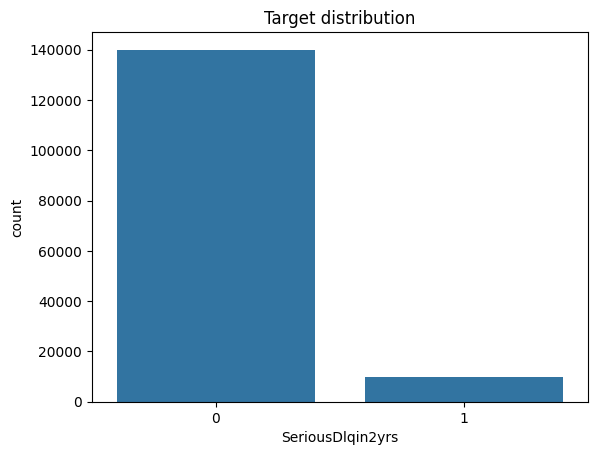

In [7]:
sns.countplot(
    x='SeriousDlqin2yrs',
    data=train
)

plt.title('Target distribution')
plt.show()

Распределение классов показывает заметный дисбаланс. Без дефолта (о) примерно 93 % и дефолт (1) примерно 7 %. Большинство клиентов в выборке не допускают серьёзной просрочки платежей, тогда как случаи дефолта встречаются значительно реже. Подобный дисбаланс является типичной особенностью задач кредитного скоринга, поскольку дефолтные клиенты составляют относительно небольшую часть всех заёмщиков. Наличие дисбаланса классов важно учитывать при обучении модели, поскольку стандартная метрика accuracy в данном случае может быть недостаточно информативной. 

Поэтому в рамках проекта особое внимание будет уделено следующим метрикам:

- Recall - способность модели находить дефолтных клиентов;
- Precision - точность предсказания дефолта;
- F1-score - баланс между precision и recall;
- ROC-AUC - качество разделения классов независимо от порога (этой метрике будет уделено особое внимание, т.к. данная метрика широко используется в банковской сфере). 

<Axes: xlabel='age', ylabel='Count'>

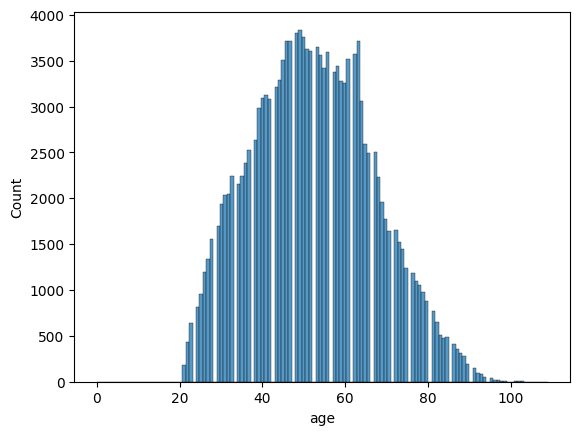

In [8]:
# посмотрим график в зависимости от возраста
sns.histplot(train['age'])

На графике представлен возрастной диапазон от 20 до почти 100 лет. График равномерно растет с 20 лет и достигает пика примерно в 50 лет. Дальше частотность снижается, но резко возрастает в примерно 62-63 гг. и снова падает до минимальных значений.

В молодости (20-30 лет) у большинства людей ещё нет сформированной кредитной истории, постоянного дохода и необходимости в крупных кредитах, поэтому количество клиентов не такое объемное. Пик графика (40-50 л.) - это возраст, когда наступает пик экономической активности и потребности в заёмных средствах (жилье, машины, образование детей и др.). А после 60 многие клиенты закрывают свои крупные кредиты, выходят на пенсию, их доход снижается, а банки менее охотно одобряют новые кредиты из-за повышенного риска по понятным для нас причинам. 


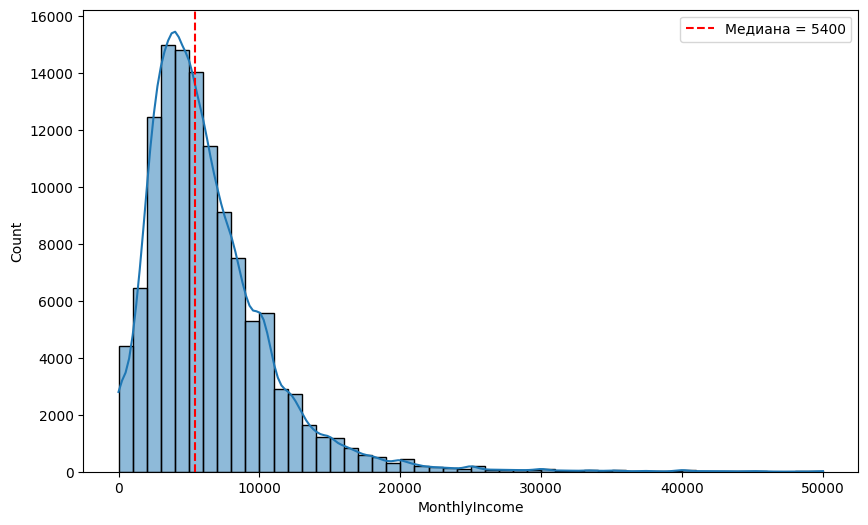

In [9]:
filtered_income = train['MonthlyIncome'].dropna()
filtered_income = filtered_income[filtered_income <= 50000]

plt.figure(figsize=(10, 6))
sns.histplot(filtered_income, bins=50, kde=True)
plt.xlabel('MonthlyIncome')
plt.ylabel('Count')
plt.axvline(filtered_income.median(), color='red', linestyle='--', label=f'Медиана = {filtered_income.median():.0f}')
plt.legend()
plt.show()

Из-за большого количества пропусков в переменной MonthlyIncome (29 731 наблюдение), что было указано выше, гистограмма построена только по доступным значениям. Также мы ограничить доход до 50 000, чтобы видеть детали у основной массы. На графике видно, что большинство клиентов, указавших доход, зарабатывают до 10 000. Медианой является значение 5400. Клиентов, чей доход находится между 10 000 и 20 000 уже намного меньше, практически меньше 2000. Дальше остаются единицы. Данный график тоже можно объяснить, ведь он соответствует логике кредитного рынка. Логично, что клиентов с меньшим доход меньше, ведт именно такой контингент нуждается в дополнительной помощи банка и обычно прибегает к его услугам.

<Axes: >

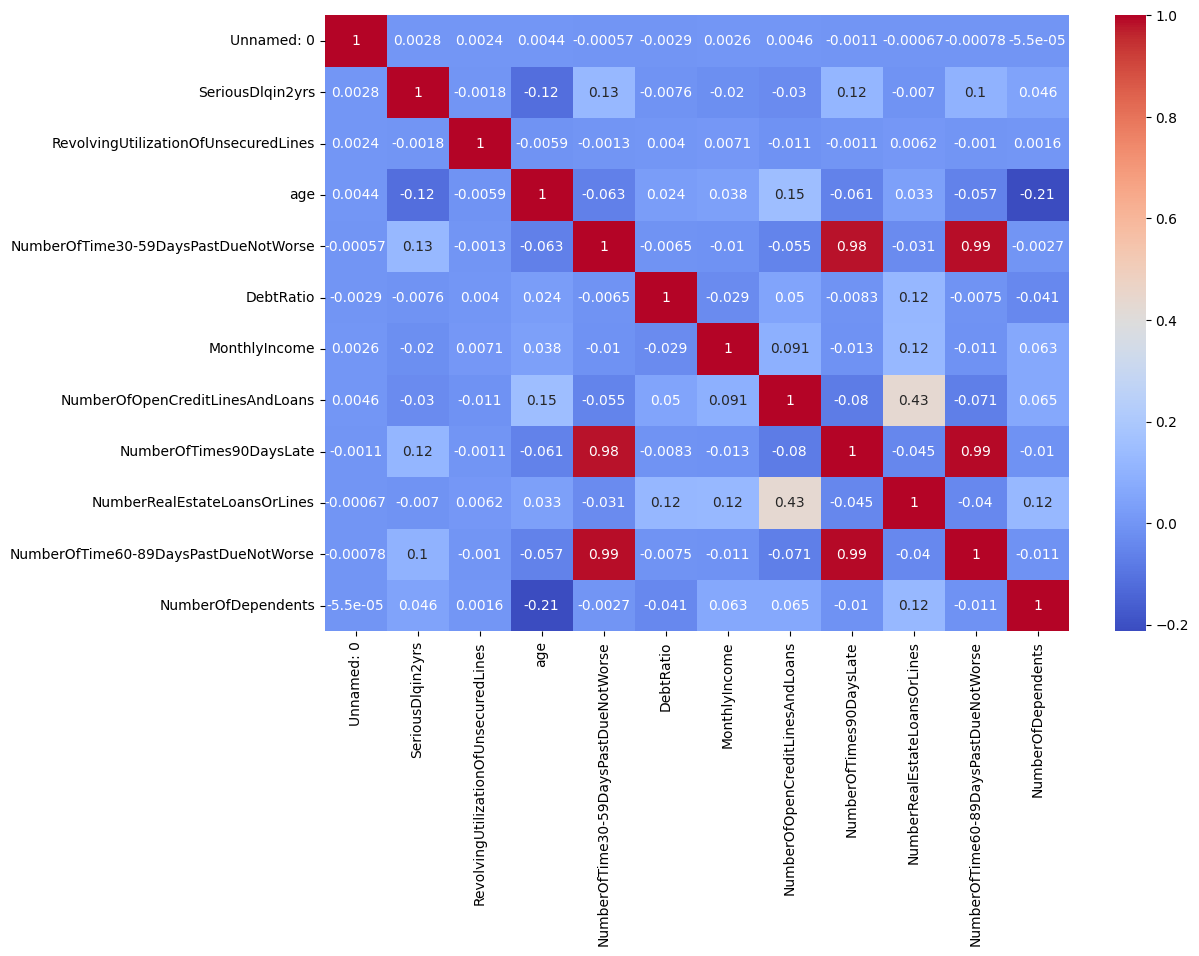

In [10]:
# корреляционная матрица
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm')

Наиболее заметная корреляция связанная с вероятностью дефолта наблюдается у показателей прошлых просрочек платежей (NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate и NumberOfTime60-89DaysPastDueNotWorse), что логично, поскольку все они отражают историю задолженностей клиента. И понятное дело, если человек не выплатил вовремя прошлый кредит,то вряд-ли ему дадут ещё один. Также обратим внимание на отрицательную корреляцию с возрастом, что значит, что у клиентов старшего возраста меньше вероятности неуплаты. То есть по матрице клиенты с наибольшим риском просрочки это -- молодые клиенты и клиенты, у которых уже были просрочки.

## Выводы по EDA
Проведённый анализ данных показал следующие особенности датасета:

- Датасет содержит 150 тысяч наблюдений и является достаточно крупным для обучения моделей машинного обучения.
- Обнаружены пропуски в признаках MonthlyIncome и NumberOfDependents.
- Целевая переменная имеет существенный дисбаланс классов (93.3% против 6.7%).
- Финансовые признаки содержат выбросы, особенно показатель ежемесячного дохода.
- Наиболее информативными признаками предположительно являются показатели просрочек платежей.
- Для оценки качества моделей целесообразно использовать ROC-AUC, Precision, Recall и F1-score.

После завершения этапа анализа данных можно переходить к предобработке данных и построению базовой модели логистической регрессии.

## 5. Предобработка данных (Data Preprocessing)

Перед обучением моделей необходимо подготовить данные: удалить служебные столбцы, обработать пропуски, разделить данные на обучающую и тестовую выборки, а также выполнить масштабирование признаков для алгоритмов, чувствительных к масштабу данных.

In [11]:
#удалим лишний столбец, потому что никакой нужной информации для исследования мы от него не получим
train = train.drop(columns=['Unnamed: 0'])
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [12]:
#разделим признаки и целевую переменную
x = train.drop("SeriousDlqin2yrs", axis=1)
y = train["SeriousDlqin2yrs"]

В качестве признаков используются финансовые показатели и кредитная история клиентов, а целевой переменной является факт наличия серьёзной просрочки платежей в течение двух лет.

In [13]:
#train.test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train:', x_train.shape)
print('Test:', x_test.shape)

Train: (120000, 10)
Test: (30000, 10)


Данные были разделены на обучающую и тестовую выборки в соотношении 80% и 20%. В результате обучающая выборка содержит 120 000 наблюдений, а тестовая - 30 000 наблюдений. Для сохранения исходного распределения классов использовалась стратификация, что особенно важно в условиях существенного дисбаланса целевой переменной. Такой подход позволяет получить более надёжную оценку качества модели на независимых данных.

In [14]:
#обработка пропусков
#для этого используется медиана
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

x_train_imputed = pd.DataFrame(
    imputer.fit_transform(x_train),
    columns=x_train.columns
)

x_test_imputed = pd.DataFrame(
    imputer.transform(x_test),
    columns=x_test.columns
)

In [15]:
x_train_imputed.isnull().sum()

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Для заполнения пропусков была выбрана медиана, поскольку финансовые признаки содержат выбросы и имеют асимметричные распределения. В отличие от среднего значения, медиана менее чувствительна к экстремальным наблюдениям. 

### Масштабирование признаков
Для моделей Logistic Regression необходимо выполнить стандартизацию признаков.

Формула стандартизации:
$$
{z} = \frac{x−μ}{σ}
$$
x - исходное значение признака;
μ - среднее значение;
σ - стандартное отклонение.

In [16]:
#масштабирование
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_imputed)
x_test_scaled = scaler.transform(x_test_imputed)

После стандартизации все признаки имеют среднее значение, близкое к нулю, и стандартное отклонение, близкое к единице. Это позволяет избежать доминирования признаков с большими числовыми значениями и улучшает работу алгоритмов, основанных на вычислении расстояний и оптимизации весов. А у нас как раз полно признаков, которые очень различаются по масштабам.

## 5. Feature engineering

Раздел, где я постараюсь улучшить данные для модели. Но т.к. все данные числовые и мы их уже привели в порядок, думаю, можно поиграться и сделать новые отношения между признаками, обработать некоторые переменные.

Например можно суммировать все просрочки клиента, чтобы получить общий риск клиента:

In [17]:
train_fe = train.copy() #делаем копию датасета, чтобы все не сломать

train_fe['TotalPastDue'] = (
    train_fe['NumberOfTime30-59DaysPastDueNotWorse']
    + train_fe['NumberOfTime60-89DaysPastDueNotWorse']
    + train_fe['NumberOfTimes90DaysLate']
)

Можно поделить доход на количество иждивенцев, чтобы проверить сколько денег приходится на одного члена семьи (но, скорее всего, это даст нам каких-то приростов к качеству):

In [18]:
train_fe['IncomePerDependent'] = (
    train_fe['MonthlyIncome'] /
    (train_fe['NumberOfDependents'] + 1)
)

И ещё разделим долг на кол-во кредитных линий, чтобы посмотреть загруженность каждого кредита (нужно помнить, что может создать шум):

In [19]:
train_fe['DebtPerCreditLine'] = (
    train_fe['DebtRatio'] /
    (train_fe['NumberOfOpenCreditLinesAndLoans'] + 1)
)

(Созданные признаки были исследованы в рамках feature engineering, однако в итоговую модель не включались, поскольку требовали дополнительной проверки влияния на качество)

## 6. Model training

В качестве базовой модели используется логистическая регрессия, которая является одним из наиболее распространённых алгоритмов для задач бинарной классификации. Логистическая регрессия оценивает вероятность принадлежности объекта к положительному классу.
Вероятность того, что клиент допустит дефолт (y=1) при заданных признаках x, вычисляется по формуле:

$$
P(y=1 \mid x) = \sigma(w^T x + b)
$$

где:
- x - вектор признаков клиента
- w - вектор весов модели
- b - смещение (bias)
- $\sigma(z)$ - сигмоидная функция

Сигмоидная функция

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Сигмоид преобразует любое действительное число $z$ в вероятность от 0 до 1.

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Regularization in Logistic Regression

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

roc_scores = []

for c in C_values:

    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=c,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ])

    score = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring='roc_auc'
    ).mean()

    roc_scores.append(score)

    print(f'C={c}: ROC-AUC={score:.4f}')

C=0.001: ROC-AUC=0.7698
C=0.01: ROC-AUC=0.7884
C=0.1: ROC-AUC=0.7905
C=1: ROC-AUC=0.7907
C=10: ROC-AUC=0.7907
C=100: ROC-AUC=0.7907


В логистической регрессии параметр C является обратным коэффициентом регуляризации:
$$
{C} = \frac{1}{λ}
$$
где:
λ — коэффициент регуляризации;
C — параметр модели.
Чем меньше значение C, тем сильнее регуляризация и тем сильнее ограничиваются веса модели.

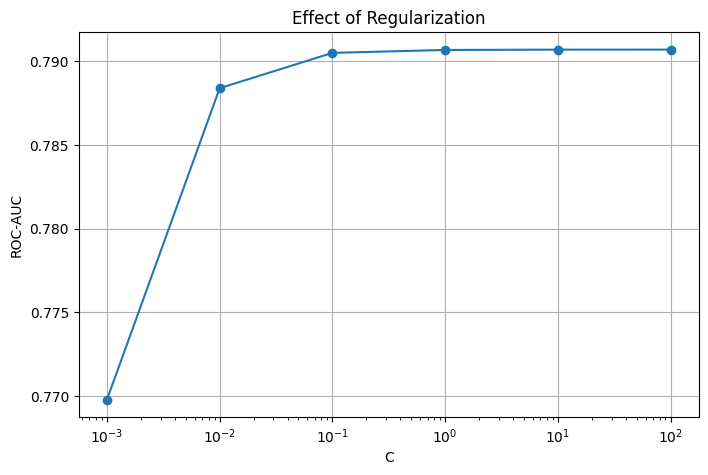

In [22]:
plt.figure(figsize=(8,5))

plt.plot(C_values, roc_scores, marker='o')

plt.xscale('log')

plt.xlabel('C')
plt.ylabel('ROC-AUC')
plt.title('Effect of Regularization')
plt.grid()

plt.show()

Из полученных результатов видно, что при очень сильной регуляризации (C=0.001) качество модели заметно снижается и ROC-AUC составляет 0.7698. Это свидетельствует о недообучении модели, поскольку регуляризация слишком сильно ограничивает значения коэффициентов и не позволяет модели использовать всю доступную информацию.
При увеличении параметра C качество постепенно улучшается. Уже при C=0.1 значение ROC-AUC достигает 0.7905, а дальнейшее увеличение параметра практически не приводит к росту качества.
Начиная с C=1, результаты стабилизируются на уровне примерно 0.791, что говорит о том, что модель достигла оптимального баланса между сложностью и способностью к обобщению.

В качестве одной из моделей был выбран алгоритм Random Forest, так как он хорошо подходит для задач бинарной классификации с табличными данными, особенно в условиях возможной нелинейности зависимостей между признаками

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train_imputed, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Добавим ещё Gradient Boosting, ведь он считается даже лучше Random Forest, тем более что наши табличные данные и бинарная классификация как раз то, что нужно для него

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(x_train_imputed, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Ещё посмотрим на Decision Tree

In [25]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

tree_model.fit(x_train_imputed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


## 7. Model evaluation

### Метрики классификации
Напоминаю, что мы решили использовать Recall, Precision, F1-score, ROC-AUC. Но здесь мы ещё на всякий случай посмотрим Accuracy, чисто для сравнения.

$$
\text{Accuracy} = \frac{TP + TN}{TN + FN + FP + TP}
$$

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} 
$$

FP - ошибка I рода

FN - ошибка II рода

Получаем предсказания: 

In [26]:
#Logistic Regression
y_pred_lr = lr_model.predict(x_test_scaled)
y_proba_lr = lr_model.predict_proba(x_test_scaled)[:, 1]

In [27]:
#Random Forest
rf_pred = rf_model.predict(x_test_imputed)
rf_proba = rf_model.predict_proba(x_test_imputed)[:, 1]

In [28]:
#Gradient Boosting
gb_pred = gb_model.predict(x_test_imputed)
gb_proba = gb_model.predict_proba(x_test_imputed)[:, 1]

In [29]:
#Decision Tree
tree_pred = tree_model.predict(x_test_imputed)
tree_proba = tree_model.predict_proba(x_test_imputed)[:, 1]

In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Decision Tree"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, tree_pred)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred),
        precision_score(y_test, tree_pred)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred),
        recall_score(y_test, tree_pred)
    ],
    
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, tree_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba),
        roc_auc_score(y_test, tree_proba)
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Gradient Boosting,0.937633,0.600601,0.199501,0.299513,0.868542
1,Random Forest,0.819833,0.231522,0.731172,0.351685,0.863603
3,Decision Tree,0.759367,0.190454,0.800000,0.307663,0.848043
0,Logistic Regression,0.776233,0.181634,0.669825,0.285775,0.802146


По данным из таблицы, видно, что логистическая регрессия показала базовый уровень качества с хорошим значением ROC-AUC, но низкой точностью. Случайный лес продемонстрировал более сбалансированные результаты и улучшение всех ключевых метрик по сравнению с базовой моделью. Градиентный бустинг показал наивысшие значения Accuracy, Precision и ROC-AUC, но при этом низкий Recall. Дерево решений показало высокий Recall, но более низкую общую точность и качество по ROC-AUC по сравнению с ансамблевыми методами С учётом специфики нашей задачи наиболее предпочтительной моделью оказался случайный лес

In [31]:
lr_auc = roc_auc_score(
    y_test,
    y_proba_lr
)

tree_auc = roc_auc_score(
    y_test,
    tree_proba
)

rf_auc = roc_auc_score(
    y_test,
    rf_proba
)

gb_auc = roc_auc_score(
    y_test,
    gb_proba
)

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'ROC-AUC': [
        lr_auc,
        tree_auc,
        rf_auc,
        gb_auc
    ]
})

results = results.sort_values(
    'ROC-AUC',
    ascending=False
)

results

,Model,ROC-AUC
3,Gradient Boosting,0.868542
2,Random Forest,0.863603
1,Decision Tree,0.848043
0,Logistic Regression,0.802146


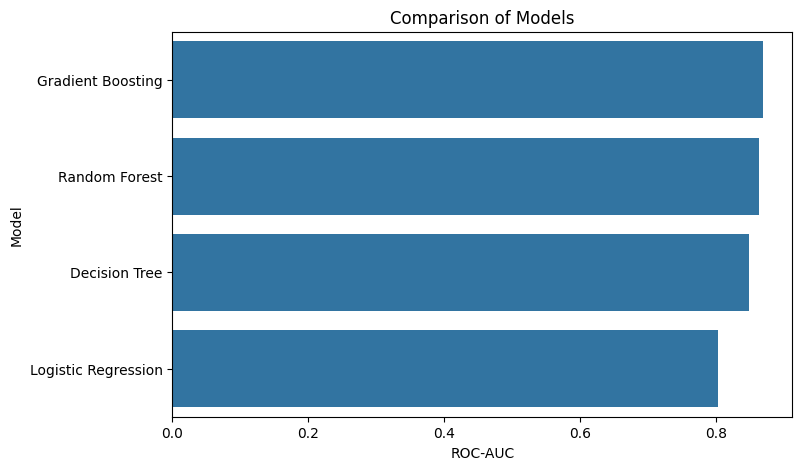

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='ROC-AUC',
    y='Model'
)

plt.title(
    'Comparison of Models'
)

plt.show()

### Матрица ошибок

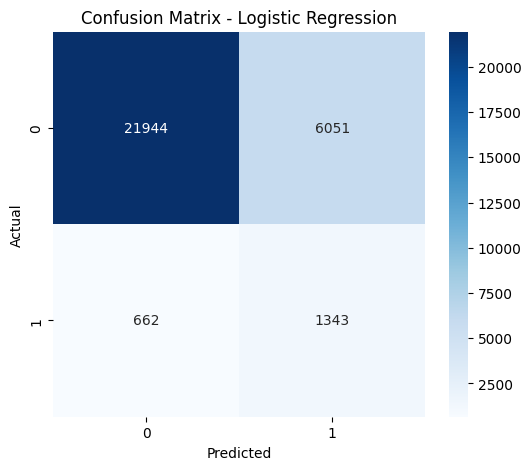

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Матрица ошибок показывает, что модель успешно распознаёт большинство клиентов без дефолта, однако часть дефолтных клиентов всё ещё классифицируется как надёжные заёмщики. Для банковской задачи такие ошибки особенно критичны, поскольку могут привести к выдаче кредита клиенту с высоким риском невозврата. Или же наоборт, мы начнем отказвать каждому 2-му и будем терять клиентов

### ROC-кривая

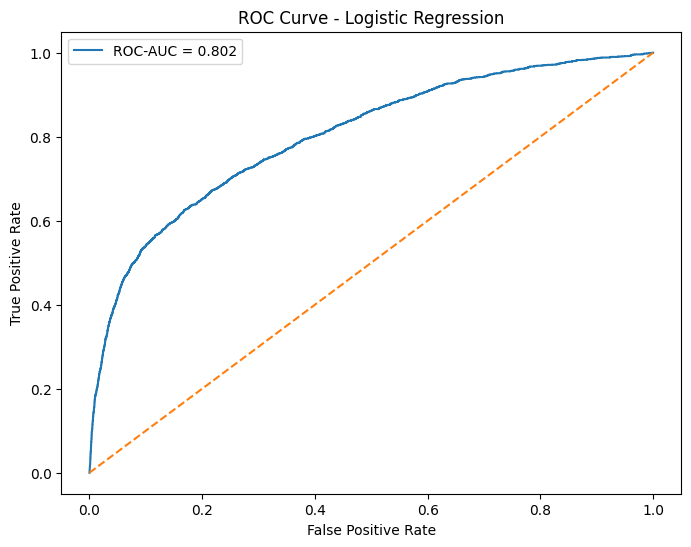

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc_score(y_test, y_proba_lr):.3f}'
)

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')

plt.legend()

plt.show()

ROC-кривая существенно располагается выше диагонали случайного классификатора, что свидетельствует о хорошей способности модели различать дефолтных и недефолтных клиентов. Значение ROC-AUC около 0.80 можно считать хорошим результатом для базовой модели кредитного скоринга.

#### 7.1 Threshold Selection (Model Tuning / Evaluation extension) 

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_proba
)

best_idx = np.argmax(tpr - fpr)

best_threshold = thresholds[best_idx]

print(best_threshold)

0.4374080694010859


In [36]:
rf_custom = (
    rf_proba >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        rf_custom
    )
)

              precision    recall  f1-score   support

           0       0.98      0.77      0.86     27995
           1       0.20      0.80      0.32      2005

    accuracy                           0.77     30000
   macro avg       0.59      0.79      0.59     30000
weighted avg       0.93      0.77      0.83     30000



Был выбран оптимальный порог классификации 0.437 вместо 0.5, что позволило изменить баланс между precision и recall. После этого Recall для дефолтных клиентов вырос до 0.80, то есть модель стала лучше выявлять рискованных клиентов. При этом Precision снизился до 0.20, что означает больше ложных срабатываний. Точность модели по классу 0 осталась высокой, но часть надёжных клиентов стала ошибочно относиться к рисковым


## 8. Model Validation

### Fold Cross Validation

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cv_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

cv_scores = cross_val_score(
    cv_pipeline,
    x,
    y,
    cv=5,
    scoring='roc_auc'
)

print("ROC-AUC на каждом фолде:")
print(cv_scores)

print(f"\nСредний ROC-AUC: {cv_scores.mean():.4f}")
print(f"Стандартное отклонение: {cv_scores.std():.4f}")

ROC-AUC на каждом фолде:
[0.78954633 0.78919341 0.78985896 0.78412806 0.80058308]

Средний ROC-AUC: 0.7907
Стандартное отклонение: 0.0054


Результаты кросс-валидации показывают, что качество модели остаётся стабильным на различных подвыборках данных. Значения ROC-AUC на всех пяти фолдах находятся в очень близком диапазоне от 0.784 до 0.801, а стандартное отклонение составляет всего 0.0054.

Небольшая вариативность результатов свидетельствует о том, что модель хорошо обобщает закономерности обучающей выборки и не зависит от конкретного разбиения данных. Это является важным признаком устойчивости модели и отсутствия выраженного переобучения.

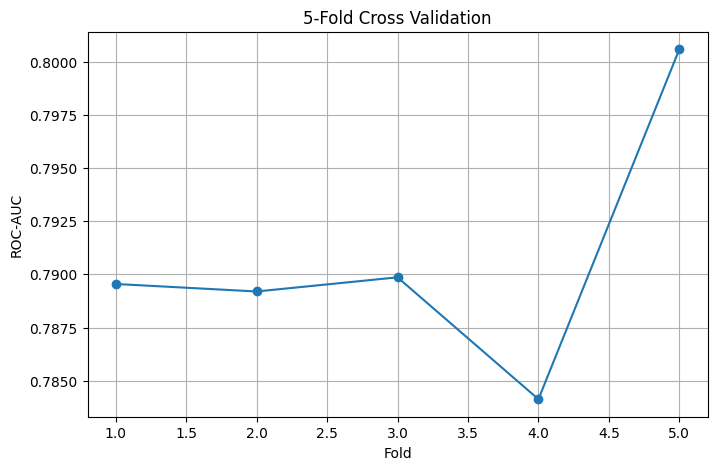

In [38]:
#визуализируем полученные результаты
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker='o'
)

plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.title('5-Fold Cross Validation')

plt.grid(True)

plt.show()

#### 9. Model interpretation

In [39]:
#важность признаков
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.363333
6,NumberOfTimes90DaysLate,0.186085
2,NumberOfTime30-59DaysPastDueNotWorse,0.170920
8,NumberOfTime60-89DaysPastDueNotWorse,0.098931
1,age,0.054159
3,DebtRatio,0.038693
4,MonthlyIncome,0.029642
5,NumberOfOpenCreditLinesAndLoans,0.029250
7,NumberRealEstateLoansOrLines,0.021929
9,NumberOfDependents,0.007057


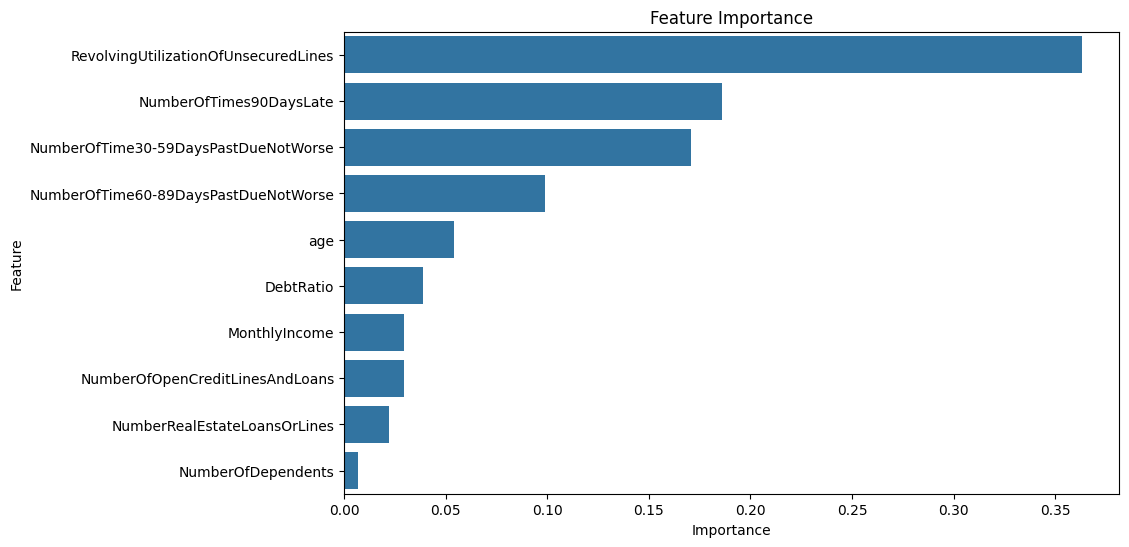

In [40]:
#визуализация
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

Наибольший вклад в прогноз модели вносят признаки, связанные с историей просрочек и использованием кредитных линий. Это соответствует банковской логике оценки риска: прошлое поведение клиента является одним из лучших индикаторов будущего дефолта.

## Conclusions & discussion

Целью данного проекта было построение моделей машинного обучения для прогнозирования кредитного дефолта клиентов на основе финансовых и демографических характеристик. Для достижения этой цели были проведены разведочный анализ данных, предварительная обработка признаков, генерация новых признаков, а также обучение и сравнение нескольких алгоритмов классификации.

Проведённый разведочный анализ показал, что выборка характеризуется выраженным дисбалансом классов: количество клиентов без дефолта значительно превышает количество клиентов, допустивших дефолт. Анализ распределений и корреляций выявил, что наибольшую связь с целевой переменной имеют признаки, связанные с историей просрочек платежей. Клиенты, имеющие случаи длительных просрочек по кредитам, существенно чаще оказываются в группе риска. Для решения задачи были обучены несколько моделей машинного обучения, включая логистическую регрессию, дерево решений, случайный лес, градиентный бустинг и дерево решений. Качество моделей оценивалось с помощью метрики ROC-AUC, которая является одной из наиболее информативных для задач бинарной классификации с несбалансированными классами.

Сравнение результатов показало, что наилучшее качество продемонстрировали ансамблевые методы, такие как Random Forest и Gradient Boosting. Их преимущество объясняется способностью учитывать сложные нелинейные зависимости между признаками и более устойчиво работать с шумом в данных. Логистическая регрессия показала хорошие результаты в качестве базовой интерпретируемой модели, однако уступила ансамблевым алгоритмам по качеству прогнозирования. Анализ важности признаков подтвердил результаты разведочного анализа: наиболее значимыми факторами кредитного риска оказались показатели, связанные с предыдущими просрочками платежей, а также характеристики использования кредитных линий. Это соответствует практическим представлениям о кредитном скоринге, поскольку прошлое финансовое поведение клиента является одним из наиболее надёжных индикаторов его будущей платёжеспособности.

Таким образом, поставленная цель исследования была достигнута. Полученные модели способны эффективно выявлять клиентов с повышенной вероятностью дефолта и могут использоваться в качестве основы для систем кредитного скоринга и оценки финансовых рисков. Среди ограничений исследования можно выделить дисбаланс классов, который может влиять на качество предсказаний для клиентов с дефолтом, а также ограниченный набор доступных признаков. В дальнейшем качество моделей может быть улучшено за счёт более тщательной настройки гиперпараметров, применения методов балансировки классов и использования дополнительных алгоритмов, таких как XGBoost или LightGBM. Также перспективным направлением является применение методов интерпретации моделей для более глубокого анализа факторов, влияющих на вероятность дефолта.
